In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
dengue_df =pd.read_csv("C:/Users/Aditya Singh/Downloads/archive (3)/dengue_cases_in_india.csv")
weather_df =pd.read_csv("C:/Users/Aditya Singh/Downloads/archive (2)/daily-rainfall-at-state-level.csv")

In [11]:
weather_df.head()

,id,date,state_code,state_name,actual,rfs,normal,deviation
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0


In [15]:
dengue_df.head()

,Num,States,2019_Cases,2019_Deaths,2020_Cases,2020_Deaths,2021_Cases,2021_Deaths,2022_Cases,2022_Deaths,2023_Cases,2023_Deaths,2024*_Cases,2024*_Deaths
0,1,Andhra Pradesh,5286,0,925,0,4760,0,6391,0,6453,0,1836,0
1,2,Arunachal Pradesh,123,0,1,0,7,0,114,0,130,0,6,0
2,3,Assam,196,0,33,0,103,0,1826,2,8208,7,270,0
3,4,Bihar,6712,0,493,2,633,2,13972,32,20224,74,7,0
4,5,Chattisgarh,722,0,57,0,1086,0,2679,10,2412,0,160,0


In [16]:
dengue_df.describe()
weather_df.describe()

,id,state_code,actual,rfs,normal,deviation
count,204876.000000,204876.000000,187714.000000,199011.000000,193358.000000,173855.000000
mean,102437.500000,19.166667,3.990693,9.643683,4.654058,38.516222
std,59142.751213,11.171668,9.512507,27.504865,7.369770,1367.744520
min,0.000000,1.000000,0.000000,0.000000,0.000000,-100.000000
25%,51218.750000,9.750000,0.000000,0.000000,0.420000,-100.000000
50%,102437.500000,18.500000,0.150000,0.063856,1.870000,-89.060000
75%,153656.250000,29.250000,3.890000,5.685068,6.760000,-9.045000
max,204875.000000,38.000000,283.000000,658.765073,97.680000,362300.000000


In [17]:
dengue_df.info()
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Num           36 non-null     int64
 1   States        36 non-null     str  
 2   2019_Cases    36 non-null     str  
 3   2019_Deaths   36 non-null     str  
 4   2020_Cases    36 non-null     int64
 5   2020_Deaths   36 non-null     int64
 6   2021_Cases    36 non-null     int64
 7   2021_Deaths   36 non-null     int64
 8   2022_Cases    36 non-null     int64
 9   2022_Deaths   36 non-null     int64
 10  2023_Cases    36 non-null     int64
 11  2023_Deaths   36 non-null     int64
 12  2024*_Cases   36 non-null     int64
 13  2024*_Deaths  36 non-null     int64
dtypes: int64(11), str(3)
memory usage: 4.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 204876 entries, 0 to 204875
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          20487

In [18]:
dengue_df =dengue_df.drop(columns='Num')

In [19]:
# 1. Fix column names (remove the asterisk from 2024)
dengue_df.columns = dengue_df.columns.str.replace('*', '', regex=False)

In [22]:
dengue_df.columns = dengue_df.columns.str.replace('*', '', regex=False)

In [43]:
# Convert 2019 columns to numeric (forces 'NR' to NaN, then we fill with 0)
dengue_df['2019_Cases'] = pd.to_numeric(dengue_df['2019_Cases'], errors='coerce').fillna(0).astype(int)
dengue_df['2019_Deaths'] = pd.to_numeric(dengue_df['2019_Deaths'], errors='coerce').fillna(0).astype(int)
# Standardize state names using a mapping dictionary
state_mapping = {
    'J & K': 'Jammu And Kashmir',
    'Chattisgarh': 'Chhattisgarh',
    'A& N Island': 'Andaman And Nicobar Islands',
    'D&N Haveli': 'The Dadra And Nagar Haveli And Daman And Diu',
    'Daman & Diu': 'The Dadra And Nagar Haveli And Daman And Diu',
    'West Bengal*': 'West Bengal'
}
dengue_df['States'] = dengue_df['States'].replace(state_mapping)

# Since Dadra & Nagar Haveli and Daman & Diu were merged, group them just in case
dengue_df = dengue_df.groupby('States', as_index=False).sum()


# Convert date to datetime object and extract the Year
weather_df['date'] = pd.to_datetime(weather_df['date'])
weather_df['Year']=weather_df['date'].dt.year

# Filter for the relevant years (2019 - 2024)
df_rain_filtered = weather_df[(weather_df['Year'] >= 2019) & (weather_df['Year'] <= 2024)].copy()

# Aggregate daily rainfall to yearly total per state
# We sum the 'actual' rainfall and ignore NaNs implicitly in .sum()
df_rain_yearly = df_rain_filtered.groupby(['state_name', 'Year'])['actual'].sum().reset_index()
df_rain_yearly.rename(columns={'actual': 'Total_Rainfall_mm'}, inplace=True)
print("Dengue Shape:", dengue_df.shape)
print("Rainfall Yearly Shape:", df_rain_yearly.shape)

Dengue Shape: (35, 13)
Rainfall Yearly Shape: (216, 3)


In [28]:
# Step 1: Create an empty list to store data for each year
all_years_data = []
# Step 2: Define the years present in dataset
years = [2019, 2020, 2021, 2022, 2023, 2024]
# Step 3: Loop through each year
for year in years:    
    # Step 3.1: Select only required columns for that year
    temp_df = dengue_df[['States', f'{year}_Cases', f'{year}_Deaths']].copy()    
    # Step 3.2: Rename columns to common names
    temp_df.rename(columns={
        'States': 'State',
        f'{year}_Cases': 'Cases',
        f'{year}_Deaths': 'Deaths'
    }, inplace=True)  
    # Step 3.3: Add a new column to indicate the year
    temp_df['Year'] = year    
    # Step 3.4: Add this year's data to the list
    all_years_data.append(temp_df)
# Step 4: Combine all yearly data into one dataframe
clean_dengue_df = pd.concat(all_years_data, ignore_index=True)
# Step 5: Display result
print(clean_dengue_df.head())

               State  Cases  Deaths  Year
0     Andhra Pradesh   5286       0  2019
1  Arunachal Pradesh    123       0  2019
2              Assam    196       0  2019
3              Bihar   6712       0  2019
4        Chattisgarh    722       0  2019


In [46]:
# We will melt cases and deaths separately, then combine them

# Melt Cases
dengue_cases = dengue_df.melt(
    id_vars=['States'], 
    value_vars=['2019_Cases', '2020_Cases', '2021_Cases', '2022_Cases', '2023_Cases', '2024_Cases'],
    var_name='Year', 
    value_name='Cases'
)
# Clean the 'Year' column to just keep the numeric year (e.g., '2019_Cases' -> 2019)
dengue_cases['Year'] = dengue_cases['Year'].str.extract(r'(\d+)').astype(int)

# Melt Deaths
dengue_deaths= dengue_df.melt(
    id_vars=['States'], 
    value_vars=['2019_Deaths', '2020_Deaths', '2021_Deaths', '2022_Deaths', '2023_Deaths', '2024_Deaths'],
    var_name='Year', 
    value_name='Deaths'
)
dengue_deaths['Year'] = dengue_deaths['Year'].str.extract(r'(\d+)').astype(int)

# Merge cases and deaths back together into a clean, long-format dengue dataset
df_dengue_long = pd.merge(dengue_cases, dengue_deaths, on=['States', 'Year'])

# Rename state_name in rainfall data to match Dengue data
df_rain_yearly.rename(columns={'state_name': 'States'}, inplace=True)

# Merge! We use an inner join to only keep matching states and years
df_master = pd.merge(df_dengue_long, df_rain_yearly, on=['States', 'Year'], how='inner')

# Feature 1: Cases-to-Rainfall Ratio (Risk Index)
# Add a small number (0.1) to rainfall to avoid division by zero
df_master['Cases_per_mm_Rain'] = df_master['Cases'] / (df_master['Total_Rainfall_mm'] + 0.1)
df_master['Cases_per_mm_Rain'] = df_master['Cases_per_mm_Rain'].round(2)

# Feature 2: Year-over-Year (YoY) Growth in Cases
# Sort by State and Year to calculate correctly
df_master = df_master.sort_values(by=['States', 'Year'])

# Calculate percentage change (Growth Rate) grouped by State
df_master['YoY_Growth_%'] = df_master.groupby('States')['Cases'].pct_change() * 100
df_master['YoY_Growth_%'] = df_master['YoY_Growth_%'].fillna(0).round(2)

# Feature 3: Mortality Rate (%)
# Out of the total cases, what percentage resulted in death?
df_master['Mortality_Rate_%'] = (df_master['Deaths'] / (df_master['Cases'] + 0.1)) * 100
df_master['Mortality_Rate_%'] = df_master['Mortality_Rate_%'].round(2)

print("Data Integration & Feature Engineering Complete!")
print("Master Dataset Shape:", df_master.shape)
display(df_master.head(10)) # Look at the new structure!

Data Integration & Feature Engineering Complete!
Master Dataset Shape: (210, 8)


,States,Year,Cases,Deaths,Total_Rainfall_mm,Cases_per_mm_Rain,YoY_Growth_%,Mortality_Rate_%
0,Andaman And Nicobar Islands,2019,168,0,0.00,1680.00,0.00,0.0
35,Andaman And Nicobar Islands,2020,98,0,0.00,980.00,-41.67,0.0
70,Andaman And Nicobar Islands,2021,175,0,0.00,1750.00,78.57,0.0
105,Andaman And Nicobar Islands,2022,1014,3,0.00,10140.00,479.43,0.3
140,Andaman And Nicobar Islands,2023,846,0,0.00,8460.00,-16.57,0.0
175,Andaman And Nicobar Islands,2024,37,0,0.00,370.00,-95.63,0.0
1,Andhra Pradesh,2019,5286,0,937.22,5.64,0.00,0.0
36,Andhra Pradesh,2020,925,0,1171.93,0.79,-82.50,0.0
71,Andhra Pradesh,2021,4760,0,1155.85,4.12,414.59,0.0
106,Andhra Pradesh,2022,6391,0,1061.14,6.02,34.26,0.0


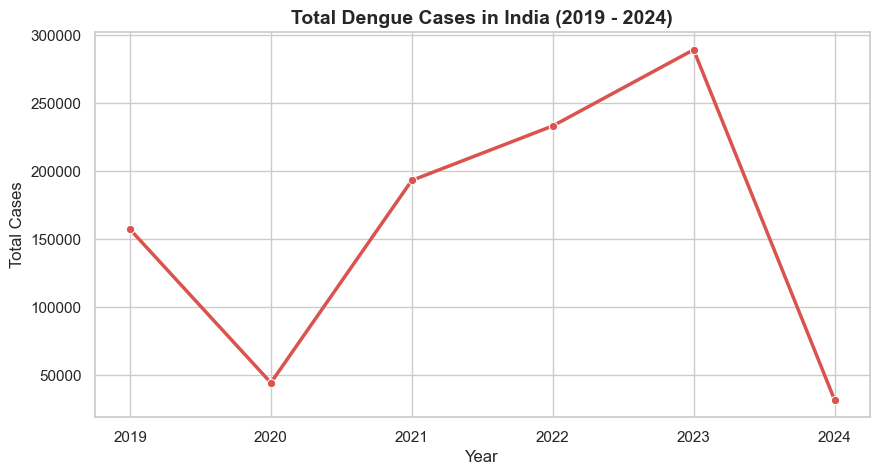

In [66]:
# Set a professional visual style
sns.set_theme(style="whitegrid")

# Plot 1: Overall Time Trend of Cases

plt.figure(figsize=(10, 5))
# We group by Year and sum the cases across all states
sns.lineplot(data=df_master, x='Year', y='Cases', estimator='sum', errorbar=None, marker='o', color='#d9534f', linewidth=2.5)
plt.title('Total Dengue Cases in India (2019 - 2024)', fontsize=14, fontweight='bold')
plt.ylabel('Total Cases')
plt.xticks(df_master['Year'].unique()) # Ensure we only show whole years
plt.show()

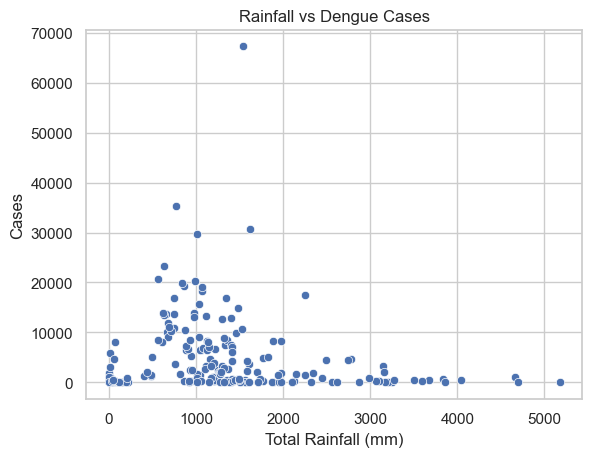

In [81]:
# Plot 2: Rainfall vs Cases

sns.scatterplot(
    data=df_master,
    x='Total_Rainfall_mm',
    y='Cases'
)

plt.title('Rainfall vs Dengue Cases')
plt.xlabel('Total Rainfall (mm)')
plt.ylabel('Cases')

plt.show()

C:\Users\Aditya Singh\AppData\Local\Temp\ipykernel_9816\496887387.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states, x='Cases', y='States', palette='magma')


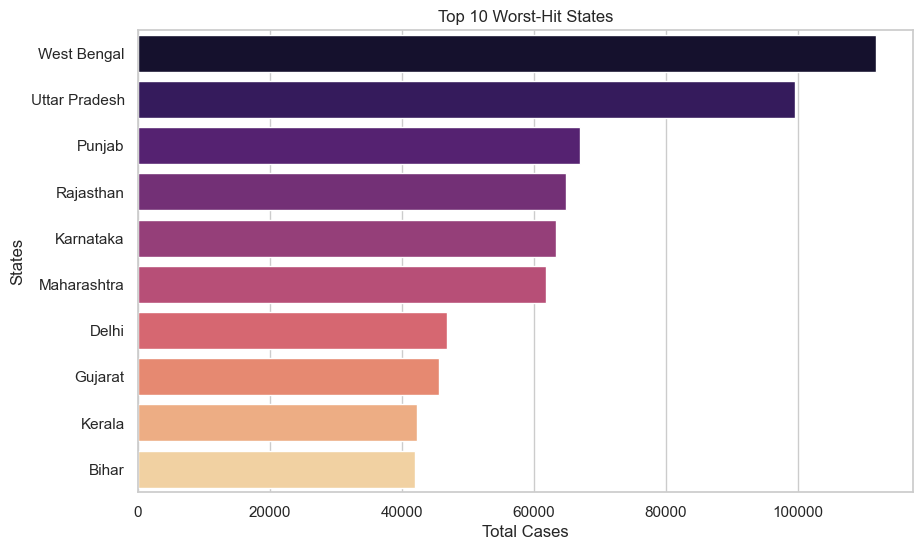

In [74]:
# Plot 3: Top 10 Worst-Hit States

top_states = df_master.groupby('States')['Cases'].sum().nlargest(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top_states, x='Cases', y='States', palette='magma')

plt.title('Top 10 Worst-Hit States')
plt.xlabel('Total Cases')
plt.ylabel('States')

plt.show()

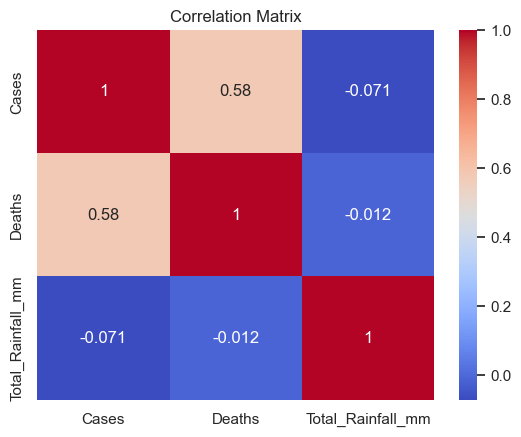

In [71]:
# Plot 4: Correlation Heatmap

# selecting useful columns
numeric_cols = df_master[['Cases', 'Deaths', 'Total_Rainfall_mm']]

# correlation
corr_matrix = numeric_cols.corr()

# plot
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()